# Aprendizaje no-Supervisado: PCA, Selección de Variables y K-Means

Este proyecto explora técnicas de reducción de dimensionalidad y agrupamiento utilizando el dataset de calidad de vino.

## 1. Carga de Datos y Configuración

In [1]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Descargar el dataset
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
df = pd.read_csv(f"{path}/WineQT.csv")

# Eliminar la columna Id si existe
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

df.head()

C:\Users\Zero\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Estandarización y PCA

Antes de aplicar PCA, estandarizamos los datos.

In [2]:
X = df.drop(columns=['quality'])
y = df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

## 3. Scree-Plot

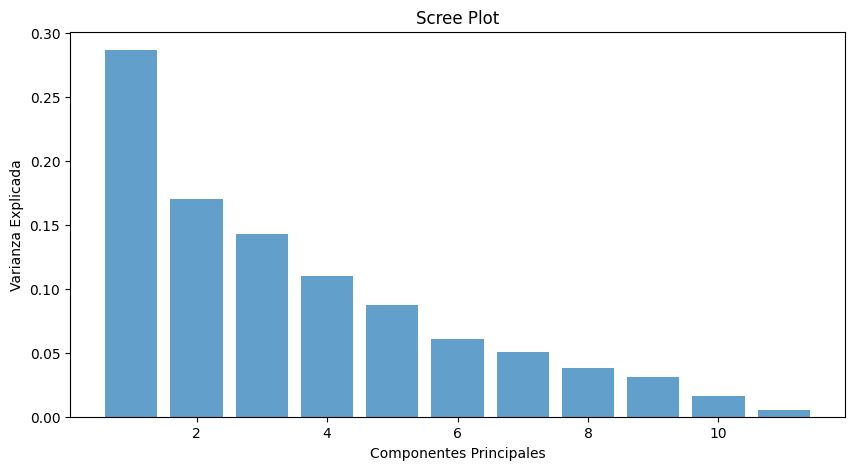

In [3]:
explained_variance = pca_full.explained_variance_ratio_
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7)
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Scree Plot')
plt.show()

## 4. Reducción a 2 Componentes Principales

In [4]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

## 5. Visualización de las 2 Componentes

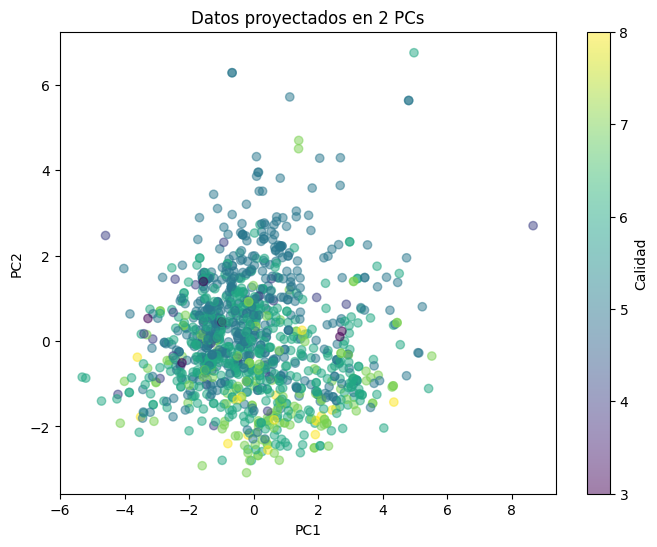

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Datos proyectados en 2 PCs')
plt.colorbar(label='Calidad')
plt.show()

## 6. Selección de Variables (Top 5)

In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
selected_features = importances.head(5).index.tolist()
X_selected = scaler.fit_transform(df[selected_features])

print(f"Variables seleccionadas: {selected_features}")

Variables seleccionadas: ['alcohol', 'sulphates', 'volatile acidity', 'total sulfur dioxide', 'pH']


## 7. Agrupamiento con K-Means

Aplicaremos K-Means sobre tres versiones del dataset:
1. Dataset Original (Estandarizado)
2. Dataset Reducido por PCA (2 Componentes)
3. Dataset con Selección de Características

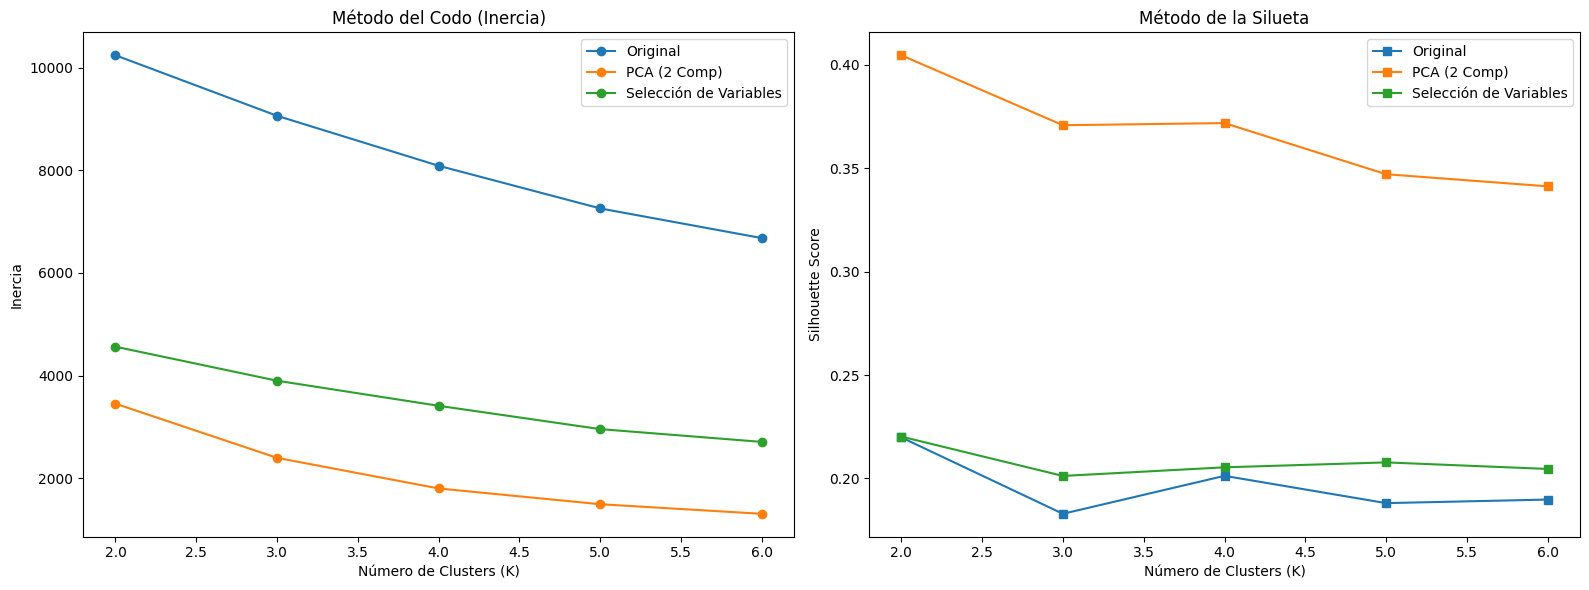

In [7]:
datasets = {
    'Original': X_scaled,
    'PCA (2 Comp)': X_pca_2,
    'Selección de Variables': X_selected
}

k_range = range(2, 7)
results = {}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, data in datasets.items():
    inertias = []
    silhouettes = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(data, kmeans.labels_))
    
    axes[0].plot(k_range, inertias, marker='o', label=label)
    axes[1].plot(k_range, silhouettes, marker='s', label=label)

axes[0].set_title('Método del Codo (Inercia)')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].legend()

axes[1].set_title('Método de la Silueta')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()